# XBTorch::Example 12:Input Encoding Modes

## Introduction

In this example, we will utilize hardware-aware inference capabilities provided by XBTorch and study the impact of input encoding modes. We will focus on the same two-layer perceptron network using the MNIST dataset that we've seen in the previous hardware-aware training examples. Like last time, any of these parts can be extended for other applications as needed.

## Getting Started

Let's import necessary dependencies.

In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import pickle
from pathlib import Path

import torch
import torch.nn as nn

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset

from functools import partial
import torch.optim as optim

In [2]:
# XBTorch imports
import xbtorch

from xbtorch.patches import xbtorch_model

from xbtorch.nn.utils import test_classifier

from xbtorch.deployment import SimpleFixedPoint, map_random, encode_simple_binary, encode_MAO, encode_LEA1, encode_LEA2, compute_error

from nets.mlp import SimpleMLP

W0528 23:15:19.468000 3163875 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0528 23:15:19.468000 3163875 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.
/mnt/osama.yousuf1/xbtorch/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Let's fix the seed for reproducibility, and initialize network and XBTorch-specific parameters.

In [3]:
seed = 0

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed) # controls weight updatejump table stochasticity

# Check if CUDA is available and select the device
device = torch.device("cuda:5" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:5


## Initialize XBTorch

Like last time, let's initialize the XBTorch library.

In [4]:
xb_size = (2500, 2500)
g_min = 133
g_max = 233
read_noise = 20
write_noise = 50
weight_encoding_scheme = encode_simple_binary
mapping_scheme = map_random
output_polling_mode = "avg"
adc_precision = dac_precision = 8

# Parameters not previously shown
stateful = False
input_encoding_scheme = "instant"

In the cell above, we initialize various XBTorch parameters pertaining to hardware-aware inference. Here's a quick summary of what thew new ones mean:

| Parameter    | Purpose |
| -------- | ------- |
| `stateful`  | Whether a physical representation of the entire crossbar should be maintained    |
| `input_encoding_scheme` | Mode for how network inputs should be applied to the crossbar      |

The primary parameter we are interested in here is the `input_encoding_scheme`. Two modes are supported:
- `instant`: Similar to voltage-amplitude encoding. The DAC applies multi-bit input voltages directly on the crossbar.
- `linear`: Linear bit-sliced temporal encoding capturing representative pulse-domain accumulation behavior. The "DAC" decomposes the input into bit slices, each slice performs a separate VMM, and partial sums are accumulated with binary weighting.

Note that for this example, ADC quantization happens after accumulation. For more details on the API, view the full XBTorch documentation.

In [5]:
inference_accelerator = SimpleFixedPoint(g_min=g_min, 
                                         g_max=g_max, 
                                         adc_bits=adc_precision, 
                                         dac_bits=dac_precision, 
                                         read_noise=read_noise, 
                                         write_noise=write_noise, 
                                         xb_size=xb_size,
                                         weight_encoding_scheme=weight_encoding_scheme, 
                                         input_encoding_scheme=input_encoding_scheme,
                                         xb_mapping_scheme=mapping_scheme,
                                         stateful=stateful,
                                         device=device)

We can now initialize XBTorch. Recall that if a parameter is not provided, default values are utilized. The reader is directed to `XBParams.__init__()` for the underlying implementation.

In [6]:
wage_params = { "wl_weight": 2, # 2 = ternary weights
                "wl_grad": 8,
                "wl_activation": 8,
                "wl_error": 8,
                "rounding_weight" : "nearest",
                "rounding_activation" : "nearest",
                "rounding_grad" : "nearest",
                "rounding_error" : "nearest",
               }

# Init xbtorch
xbtorch.initialize(pytorch_device=device,
                   inference_accelerator=inference_accelerator,
                   wage_quantize=True, # since the trained solution utilized wage quantization
                   wage_params=wage_params
                   )

## Prepare the dataset

We can now prepare the dataset for our neural network.

In [7]:
# Define transforms to apply to the data
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize the image data
])

# Load the MNIST training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders for batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True, generator=torch.Generator(), num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=10000, shuffle=False, generator=torch.Generator(), num_workers=4)

## Prepare the model

We simply instantiate and load the state dictionary of our HWA pre-trained simple 2-layer perceptron network. 

In [8]:
# Define the model
input_size = 28 * 28
hidden_size = 150
output_size = 10

# Create Model
model = SimpleMLP(input_size, hidden_size, output_size).to(device)
model = xbtorch_model(model)

# Override state dict. 
# If we had dumped the final state_dict directly, model.load_state_dict(torch.load(..)) could be used instead
with open("checkpoints/hwa_train_mlp_hwa_example.pkl", "rb") as f:
    full_weights_hwa = pickle.load(f)
    
epoch = -1 # load last epoch's weights

for name, param in model.named_parameters():
    new_tensor = torch.from_numpy(full_weights_hwa[name][epoch, ...]).to(
        device=param.device,
        dtype=param.dtype,
    )
    param.data = new_tensor

## Baseline performance

We can firstly compute the baseline test accuracy of our network. This is the accuracy before activating the inference accelerator (i.e. all computations of the network happen without the accelerator primitive's intervention).

In [9]:
baseline_acc, _ = test_classifier(test_loader, model, device)

print(baseline_acc)

89.7


## Network Performance w/ Instant Encoding

We can now study the HWA inference performance with instant encoding of the inputs. The linear mode introduces extra quantization events, so it is interesting to study how the two fare against one another under the presence of other non-idealities. For example, one could sweep read noise as a representative non-ideality and compare the overall network performance. For now, we will keep things simple and compare the two while keeping other parameters unchanged.

In [10]:
iterations = 10

# Step 1: Enable evaluation on the inference accelerator
model.xb_eval()

instant_encoding_accs = np.zeros((iterations,))

for i in range(iterations):
    print(f"\nIteration {i+1}")
    # Step 2: Clear previous mappings
    inference_accelerator.initialize_chip()
    # Step 2: Initialize array mappings

    if stateful:
        model.initialize_array_mappings(output_polling_mode=output_polling_mode, 
                                        additional_args={}, 
                                        existing_mappings=[]
                                       )

    # Step 3:  Test the performance like before!
    acc, _ = test_classifier(test_loader, model, device)
    instant_encoding_accs[i] = acc


Iteration 1

Iteration 2

Iteration 3

Iteration 4

Iteration 5

Iteration 6

Iteration 7

Iteration 8

Iteration 9

Iteration 10


## Network Performance w/ Linear Encoding

Let's repeat the same network's performance experiment with linear encoding.

In [11]:
# Instantiate new accelerator

input_encoding_scheme = "linear"

inference_accelerator = SimpleFixedPoint(g_min=g_min, 
                                         g_max=g_max, 
                                         adc_bits=adc_precision, 
                                         dac_bits=dac_precision, 
                                         read_noise=read_noise, 
                                         write_noise=write_noise, 
                                         xb_size=xb_size,
                                         weight_encoding_scheme=weight_encoding_scheme, 
                                         input_encoding_scheme=input_encoding_scheme,
                                         xb_mapping_scheme=mapping_scheme,
                                         stateful=stateful,
                                         device=device)

# Reload model

model = SimpleMLP(input_size, hidden_size, output_size).to(device)
model = xbtorch_model(model)

with open("checkpoints/hwa_train_mlp_hwa_example.pkl", "rb") as f:
    full_weights_hwa = pickle.load(f)
    
epoch = -1 # load last epoch's weights

for name, param in model.named_parameters():
    new_tensor = torch.from_numpy(full_weights_hwa[name][epoch, ...]).to(
        device=param.device,
        dtype=param.dtype,
    )
    param.data = new_tensor

In [12]:
# Step 1: Enable evaluation on the inference accelerator
model.xb_eval()

linear_encoding_accs = np.zeros((iterations,))

for i in range(iterations):
    print(f"\nIteration {i+1}")
    # Step 2: Clear previous mappings
    inference_accelerator.initialize_chip()
    # Step 2: Initialize array mappings

    if stateful:
        model.initialize_array_mappings(output_polling_mode=output_polling_mode, 
                                        additional_args={}, 
                                        existing_mappings=[]
                                       )

    # Step 3:  Test the performance like before!
    acc, _ = test_classifier(test_loader, model, device)
    linear_encoding_accs[i] = acc


Iteration 1

Iteration 2

Iteration 3

Iteration 4

Iteration 5

Iteration 6

Iteration 7

Iteration 8

Iteration 9

Iteration 10


## Visualization

Let's visualize the effect of input encoding mode on network performance.

/tmp/ipykernel_3163875/3332972988.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


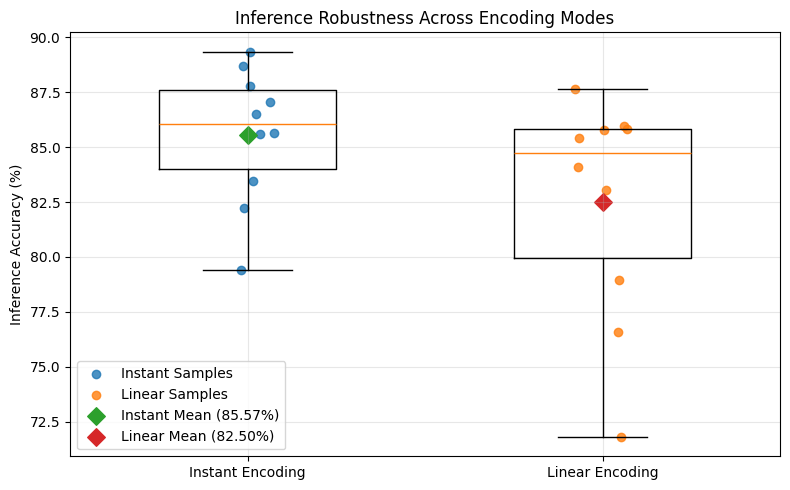

In [13]:
xs = np.arange(1, iterations + 1)

plt.figure(figsize=(8, 5))

# Boxplots
plt.boxplot(
    [instant_encoding_accs, linear_encoding_accs],
    positions=[1, 2],
    widths=0.5,
    labels=["Instant Encoding", "Linear Encoding"]
)

# Scatter overlay
plt.scatter(
    np.ones_like(instant_encoding_accs) + np.random.uniform(-0.08, 0.08, len(instant_encoding_accs)),
    instant_encoding_accs,
    alpha=0.8,
    label="Instant Samples"
)

plt.scatter(
    2 * np.ones_like(linear_encoding_accs) + np.random.uniform(-0.08, 0.08, len(linear_encoding_accs)),
    linear_encoding_accs,
    alpha=0.8,
    label="Linear Samples"
)

# Mean markers
plt.scatter(1, np.mean(instant_encoding_accs), marker='D', s=80,
            label=f'Instant Mean ({np.mean(instant_encoding_accs):.2f}%)')

plt.scatter(2, np.mean(linear_encoding_accs), marker='D', s=80,
            label=f'Linear Mean ({np.mean(linear_encoding_accs):.2f}%)')

plt.ylabel("Inference Accuracy (%)")
plt.title("Inference Robustness Across Encoding Modes")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Conclusion

This notebook demonstrates that input encoding strategy can materially influence inference robustness under hardware nonidealities. In this particular example, instantaneous encoding achieves higher average accuracy than linear bit-sliced encoding; however, this outcome is strongly dependent on the underlying hardware assumptions and operating conditions.

Specifically, the present experiments assume device operation within the linear regime and use identical `V_read` values for both encoding modes. Under these conditions, the temporal decomposition introduced by linear encoding primarily introduces additional quantization overhead without providing compensating benefits. Furthermore, the `SimpleFixedPoint` inference accelerator employs dynamic output quantization, which prevents ADC saturation and clipping effects that could otherwise favor temporally encoded execution.

Different modeling assumptions may lead to different conclusions. For example, if the device model incorporated voltage-dependent nonlinearities such that larger instantaneous voltages pushed devices outside their linear operating region, linear bit-sliced encoding would likely offer improved robustness. Similarly, architectures with fixed ADC ranges, saturation behavior, or explicit clipping could benefit from temporal accumulation strategies.

These experiments therefore highlight not only the importance of encoding choice, but also the flexibility of XBTorch’s modular accelerator interface. Existing parameters can be swept to explore alternate operating regimes, and users can readily implement custom inference accelerator profiles with more complex transfer functions, enabling evaluation of architecture-specific encoding schemes tailored to their target IMC hardware.